# Projet : Prédiction du Diabète  
## Objectifs  
Ce projet vise à :  
- Construire un modèle de Machine Learning capable de prédire si un patient est diabétique ou non.  
- Explorer les facteurs influençant le diabète à partir des données fournies.  

## Contexte  
- Le jeu de données contient des informations médicales anonymisées.  
- Le projet permettra de mieux comprendre les relations entre les variables et d'identifier les indicateurs clés de la santé.  

## Approche  
1. Analyse exploratoire des données (EDA) pour mieux comprendre le jeu de données.  
2. Prétraitement des données pour préparer les entrées au modèle.  
3. Construction et évaluation du modèle avec des métriques adaptées (e.g., précision, rappel).  


##1.1 EDA : Exploratory Data Analysis


In [ ]:
# importer le dataset train.csv

import kagglehub
import pandas

path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

df = pandas.read_csv(path + "/diabetes_prediction_dataset.csv")
df.head()


100%|██████████| 734k/734k [00:00<00:00, 18.3MB/s]

Extracting files...


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


On voit que le tableau de données comporte 9 colonnes avec différentes indicateurs de santé.
Afin de traiter plus simplement les données pour la suite, on va changer les valeurs de la colonne "smoking_history" en camelcase

In [ ]:
# transforme smoking_history in camelcase
df1 = df.copy()
df1['smoking_history'] = df1['smoking_history'].str.replace(' ', '_').str.lower()
df1.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,no_info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<Axes: >

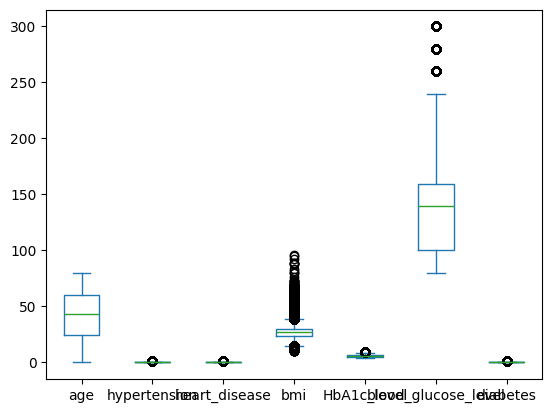

In [ ]:
# Créer un box plot pour visualiser la distribution des variables numériques
df1.plot.box()

<Axes: >

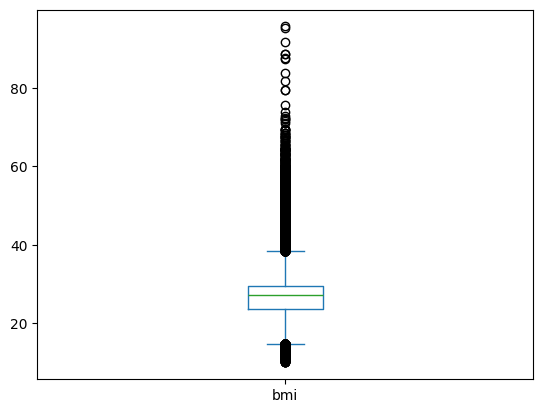

In [ ]:
# La boîte à moustache de Bmi présente beaucoup d'anomalies : il faut les justifier
# Je l'affiche en plus gros
df1[['bmi']].plot.box()

<Axes: ylabel='Frequency'>

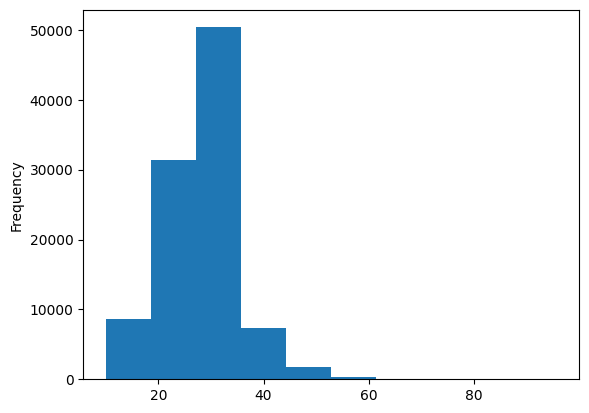

In [ ]:
df.bmi.plot.hist()

Les valeurs de bmi ne semblent pas aberrantes, donc on peut continuer à les utiliser pour notre model pour le moment

Afin de mieux comprendre la colonne "smoking_history", on va venir afficher l'ensemble de ses valeurs

In [ ]:
df1['smoking_history'].unique()

array(['never', 'no_info', 'current', 'former', 'ever', 'not_current'],
      dtype=object)

On sait maintenant qu'il y a 6 valeurs différentes

Maintenant qu'on en sait un peu plus sur chaque colonne et sur les données au globales, on va venir faire différents graphs afin de déterminer ce qui va vraiment être impactant pour l'efficacité de notre model et ce qui ne va pas l'être.

Pour commencer, on va visualiser la relation entre le niveau de glucose dans le sang et la maladie qu'on recherche : le diabète

In [ ]:
import plotly.express as px
px.scatter(df1, x='blood_glucose_level', y='age', color='diabetes')

Ici, on observe que le taux de glucose dans le sang a un rapport direct avec la détection de la maladie, car à partir de 220mg/dL, un patient est forcément diabétique.

Observons maintenant une autre donnée qui semble être importante : le taux d'hémoglobine (HbA1c_level)

In [ ]:
px.scatter(df1, x='HbA1c_level', y='age', color='diabetes')

On voit également que cette donnée est primordiale sur la détection de la maladie car au dessus de 6.8%, un patient est également atteint de diabète, et au contraire en dessous de 5% ne peut pas l'être

On va maintenant tester différentes données pour voir l'importance de chacune d'entre-elle

In [ ]:
# Visualiser la relation entre 'age', 'bmi' et 'diabetes'
px.scatter(df1, x='age', y='bmi', color='diabetes')

In [ ]:
px.scatter(df1, x='gender', y='age', color='diabetes')

In [ ]:
px.scatter(df1, x='smoking_history', y='age', color='diabetes')

Après ces deux graphiques, on peut constater que l'âge et le bmi (IMC en fr) on un rôle plutôt important car plus un patient prend de l'âge et plus il a un bmi important, plus ses chances d'avoir la maladie sont importantes

Maintenant on veut voir la même chose pour l'hypertension et le "heart_disease", seulement leurs valeurs ne sont égales qu'à 0 et 1, ce qui rend les graphiques précédent inexploitable car cela donne ça :

In [ ]:
px.scatter(df1, x='hypertension', y='heart_disease', color='diabetes')

Comme on le voit, on ne peut rien exploiter de ces valeurs. On va donc faire un tableau croisé afin d'avoir une vue globale sur les rapports entre les deux données et le diabète

In [ ]:
# Création d'un tableau croisé
cross_tab = pandas.crosstab(
    [df1['heart_disease'], df1['hypertension']],
    df1['diabetes'],
    normalize='index'  # Pourcentage par ligne
) * 100

# Renommer les colonnes et arrondir les pourcentages
cross_tab.columns = ['Diabetes = 0', 'Diabetes = 1']
cross_tab = cross_tab.round(2)

# Afficher le tableau
print("Tableau de pourcentages :\n", cross_tab)

Tableau de pourcentages :
                             Diabetes = 0  Diabetes = 1
heart_disease hypertension                            
0             0                    93.85          6.15
              1                    73.66         26.34
1             0                    69.96         30.04
              1                    60.92         39.08


Pour mieux comprendre visuellement les données, on va les afficher dans un graphique en barres empilées

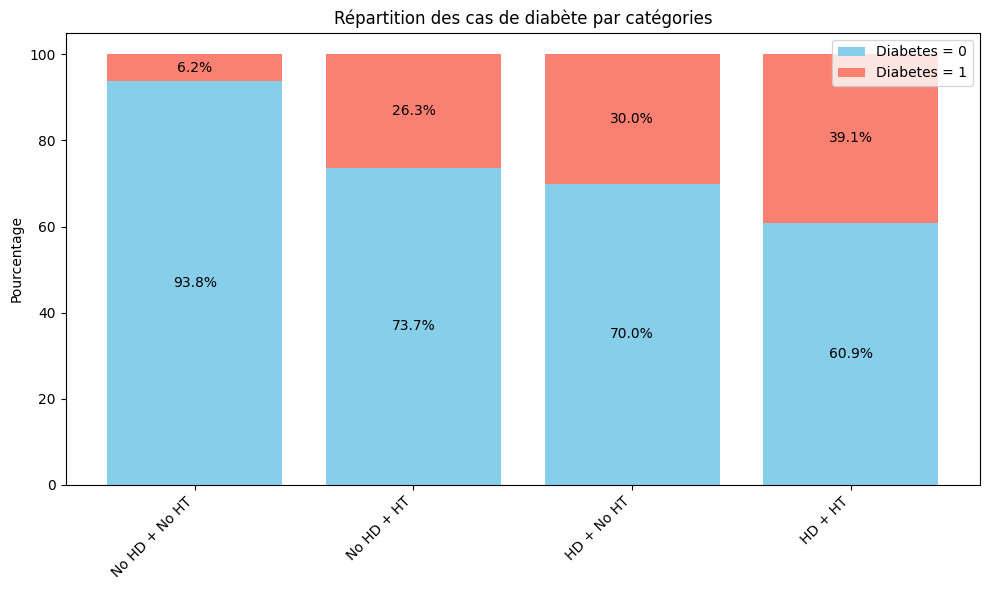

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Données
categories = ["No HD + No HT", "No HD + HT", "HD + No HT", "HD + HT"]

diabetes_0 = [93.85, 73.66, 69.96, 60.92]
diabetes_1 = [6.15, 26.34, 30.04, 39.08]

# Position des barres
x = np.arange(len(categories))

# Création du graphique en barres empilées
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x, diabetes_0, label="Diabetes = 0", color="skyblue")
ax.bar(x, diabetes_1, bottom=diabetes_0, label="Diabetes = 1", color="salmon")

# Ajout des labels et des titres
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")
ax.set_ylabel("Pourcentage")
ax.set_title("Répartition des cas de diabète par catégories")
ax.legend()

# Ajout des annotations (pourcentage sur les segments)
for i, (d0, d1) in enumerate(zip(diabetes_0, diabetes_1)):
    ax.text(i, d0 / 2, f"{d0:.1f}%", ha="center", va="center", color="black")
    ax.text(i, d0 + d1 / 2, f"{d1:.1f}%", ha="center", va="center", color="black")

# Afficher le graphique
plt.tight_layout()
plt.show()

On voit bien que l'hypertension et les maladies du coeur sont deux facteurs important à la détection du diabète

On va commencer à travailler sur les models et les différents tris dans notre tableau de données

In [ ]:
# Modifie les valueurs "string" en "int" pour éviter les erreurs de trier dans les tableaux
df1.replace({'Male': 0, "Female":1, "Other":2}, inplace=True)
df1.replace({'never': 0, "no_info":1, "current":2, 'former': 3, "ever":4, "not_current":5}, inplace=True)

In [ ]:
# Affichage de la forme du DataFrame (nombre de lignes, nombre de colonnes) et de la proportion de diabétiques
print("Nb de lignes / colonnes :", df1.shape)
print("-"*10)
print(df1['diabetes'].value_counts(normalize=True) * 100)

Nb de lignes / colonnes : (100000, 9)
----------
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


On observe ici une chose qui risque grandement de nous proposer problème sur la suite et le développement de notre model, c'est que sur les 100 000 lignes de données, uniquement 8500 patients sont diabétiques.

À cause de cela, la valeur de 8.5% est beaucoup trop basse pour être autant précise que les 91 autres %. On va donc prendre au hasard 8500 patients non-diabétique afin d'avoir le même nombre de chaque côté.

In [ ]:
# Filtrage entre les diabétiques et les non-diabétiques
diabetic_patients = df1[df1['diabetes'] == 1]
non_diabetic_patients = df1[df1['diabetes'] == 0]

# Sample 8500 pour chaque groupe
diabetic_sample = diabetic_patients.sample(n=min(8500, len(diabetic_patients)), random_state=42)
non_diabetic_sample = non_diabetic_patients.sample(n=8500, random_state=42)


Maintenant que nos données sont filtrées, on va pouvoir créer notre premier model dit "témoin", c'est-à-dire le model qui utilise l'entièreté des colonnes pour ensuite tester différentes formes et voir laquelle sera la plus précise

In [ ]:
# Modèle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Création du model témoin
model0 = pandas.concat([diabetic_sample, non_diabetic_sample])

# Enregistrement des colonnes et de la cible
features = ["gender", "hypertension", "heart_disease", "age", "bmi", "HbA1c_level", "blood_glucose_level", "smoking_history"]
target = "diabetes"

X = model0[features]
y = model0[target]

# Diviser les données en ensembles d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Créer et entraîner un modèle de régression logistique
clf = LogisticRegression()
clf.fit(x_train, y_train)

# Afficher les coefficients du modèle
print("coef:", clf.coef_)

print("-"*10)

# Afficher les scores d'entraînement et de test
print("Train score :", clf.score(x_train, y_train) * 100)
print("Test  score :", clf.score(x_test, y_test) * 100)

print("-"*10)

print(x_test[0:1])
print("-"*10)
clf.predict(x_test[0:1])

coef: [[ 0.40122149  3.80049309  2.71467727  0.03052821  0.0456016   1.42615044
   0.02688011 -0.21129526]]
----------
Train score : 85.66176470588235
Test  score : 87.1470588235294
----------
       gender  hypertension  heart_disease   age    bmi  HbA1c_level  \
17328       1             0              0  27.0  23.91          5.0   

       blood_glucose_level  smoking_history  
17328                  160                1  
----------


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



array([0])

D'après ce premier model, on va déjà un taux de précision de 85% environ, ce qui n'est pas abérrant au vu du peu nombre de colonnes que l'on exploite dans notre dataset

On va tester un modèle en retirant la catégorie Other de "gender" car sur un précédent graphique, on avait ou voir que cette dernière ne contenait que des patients non-diabétiques, et peut donc fausser le pronostique de notre model

In [ ]:
# Créer un modèle sans la catégorie "Other" pour le genre
model1 = model0.copy(deep=True).drop(model0[model0['gender'] == 2].index, axis=0)



features = ["gender", "hypertension", "heart_disease", "age", "bmi", "smoking_history", "HbA1c_level", "blood_glucose_level"]
target = "diabetes"

X = model1[features]
y = model1[target]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(x_train, y_train)

print("Train score :", clf.score(x_train, y_train) * 100)
print("Test  score :", clf.score(x_test, y_test) * 100)

print("-"*10)

print(x_test[0:1])
print("-"*10)
clf.predict(x_test[0:1])

Train score : 85.73319605824385
Test  score : 85.61764705882354
----------
      gender  hypertension  heart_disease   age    bmi  smoking_history  \
7422       0             0              0  32.0  27.32                1   

      HbA1c_level  blood_glucose_level  
7422          4.0                  160  
----------


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



array([0])

Après test, on se rend compte que cette catégorie "Other" n'a pas l'air d'influencer sur le pronostique du model comme le taux de précision reste à 85% environ

Testons maintenant un model qui n'a pas de "smoking_history", car on a pu voir dans les graphiques également que ce paramètre n'avait pas l'air d'avoir une grande importance

In [ ]:
# Créer un modèle sans la variable "smoking_history"
model2 = model0.copy(deep=True).drop(['smoking_history'], axis=1)

features = ["gender", "hypertension", "heart_disease", "age", "bmi", "HbA1c_level", "blood_glucose_level"]
target = "diabetes"

X = model2[features]
y = model2[target]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(x_train, y_train)

print("Train score :", clf.score(x_train, y_train) * 100)
print("Test  score :", clf.score(x_test, y_test) * 100)

print("-"*10)

print(x_test[0:1])
print("-"*10)
clf.predict(x_test[0:1])

Train score : 88.21323529411764
Test  score : 88.97058823529412
----------
       gender  hypertension  heart_disease   age    bmi  HbA1c_level  \
17328       1             0              0  27.0  23.91          5.0   

       blood_glucose_level  
17328                  160  
----------


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



array([0])

D'après ce model, on monte jusqu'à 88% de précision, ce qui est mieux que notre précédent test, et démontre que ce paramètre n'était pas utile et ralentissait le potentiel du model

Accuracy: 85.73%
Accuracy: 85.62%


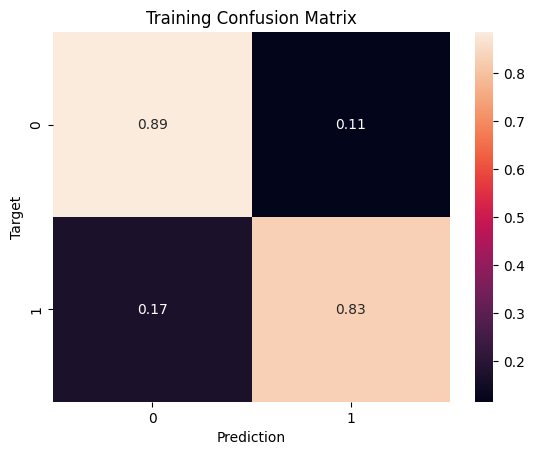

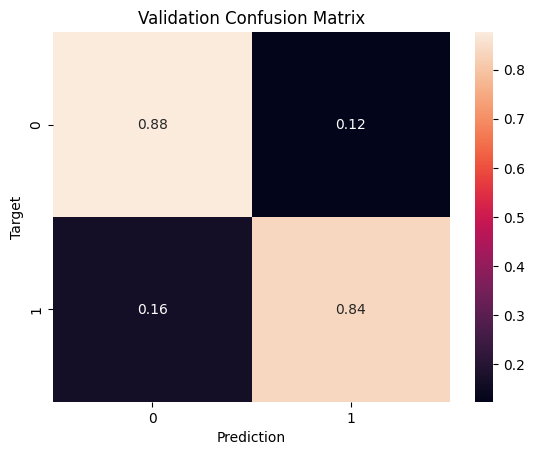

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Définir une fonction pour prédire et afficher la matrice de confusion
def predict_and_plot(model, inputs, targets, name=''):
    preds = model.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))

    return preds

# Predict and plot on the training data
train_preds = predict_and_plot(clf, x_train, y_train, 'Training')

# Predict and plot on the validation data
val_preds = predict_and_plot(clf, x_test, y_test, 'Validation')

Afin d'être certain de ne pas utiliser la colonne "smoking_history", on va créer un model qui va uniquement contenir ce paramètre pour voir son taux de précision

In [ ]:
# Créer un modèle avec seulement "smoking_history"
model3 = model0.copy(deep=True).drop(['HbA1c_level', "blood_glucose_level", "bmi", "gender", "hypertension", "heart_disease", "age"], axis=1)

features = ["smoking_history"]
target = "diabetes"

X = model3[features]
y = model3[target]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(x_train, y_train)

print("Train score :", clf.score(x_train, y_train) * 100)
print("Test  score :", clf.score(x_test, y_test) * 100)

print("-"*10)

print(x_test[0:1])
print("-"*10)
clf.predict(x_test[0:1])

Train score : 58.18382352941176
Test  score : 57.529411764705884
----------
       smoking_history
17328                1
----------


array([0])

On voit bien qu'il a un taux quasi nul de 50%, ce qui rend totalement le "smoking_history" obsolète

Pour maintenant vérifier les données de "blood_glucose_level" et "HbA1c_level", qui paraissait primordiaux d'après les graphiques, faisons un model qui ne possède pas ces derniers

In [ ]:
# Créer un modèle sans "blood_glucose_level" et "HbA1c_level"
model4 = model0.copy(deep=True).drop(["blood_glucose_level",'HbA1c_level'], axis=1)

features = ["bmi",  "gender", "heart_disease", "age", "smoking_history", "hypertension"]
target = "diabetes"

X = model4[features]
y = model4[target]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(x_train, y_train)
print("coef:", clf.coef_)

print("Train score :", clf.score(x_train, y_train) * 100)
print("Test  score :", clf.score(x_test, y_test) * 100)

print("-"*10)

print(x_test[0:1])
print("-"*10)
clf.predict(x_test[0:1])

coef: [[ 0.10052244 -0.31439908  0.94208213  0.04872512  0.05749805  0.96929255]]
Train score : 75.05882352941177
Test  score : 76.02941176470588
----------
         bmi  gender  heart_disease   age  smoking_history  hypertension
17328  23.91       1              0  27.0                1             0
----------


array([0])

On voit bien que le taux de précision à baisser de 10% par rapport au témoin, ce qui démontre l'importance de ces colonnes dans notre model final

Après ces différents tests de model, on voit que le plus précis est le deuxième, qui ne possède pas le paramètre "smoking_history", et qui possède des colonnes "médicales" comme le taux d'hémoglobine, le glucose dans le sang, l'hypertension et les maladies du coeur